In [1]:
import getdist.plots as gdplt
from cobaya import load_samples
import matplotlib.pyplot as plt
import numpy as np
import camb
import cosmoprimo
import matplotlib.cm as cm
import matplotlib.colors as mcolors

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('font', size=14)
plt.rc('axes', labelsize=16)

# looking at distances values on degeneracy line

In [3]:
path = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\base_w_wa\run1'
gd_sample = load_samples(path, to_getdist=True, skip=0.33)
var_names = ['hrdrag', 'omm', 'w', 'wa']
# gdplot = gdplt.get_subplot_plotter()
# gdplot.triangle_plot(gd_sample, var_names, filled=True)

### degeneracy lines 

### $\alpha_\perp, \ \alpha_\parallel$

In [2]:
def alpha_perp_parallel(z, cosmo_params):
    '''
    alpha_perp = (DM(z)/rd) / (DM_fid(z)/rd_fid)
    alpha_parallel = (DH(z)/rd) / (DH_fid(z)/rd_fid)
    fid --> the DESI fiducial cosmology
    '''

    w0, wa, Omega_m, hrdrag = cosmo_params

    DESI = cosmoprimo.fiducial.DESI(engine='camb')
    DESI_bkg = DESI.get_background()
    DESI_thermo = DESI.get_thermodynamics()
    rdrag_fid = DESI_thermo.rs_drag
    DM_fid = DESI_bkg.comoving_angular_distance(z)
    DH_fid = 1 / DESI_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_fid = (z * DM_fid**2 * DH_fid)**(1/3)
    DMover_rd_fid = DM_fid / rdrag_fid
    DHover_rd_fid = DH_fid / rdrag_fid
    DVover_rd_fid = DV_fid / rdrag_fid

    custom_cosmo = cosmoprimo.Cosmology(w=w0, wa=wa, Omega_m=Omega_m)
    custom_bkg = custom_cosmo.get_background(engine='camb')
    DM_real = custom_bkg.comoving_angular_distance(z)
    DH_real = 1 / custom_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_real = (z * DM_real**2 * DH_real)**(1/3)
    DMover_rd_real = DM_real / hrdrag
    DHover_rd_real = DH_real / hrdrag
    DVover_rd_real = DV_real / hrdrag
    
    return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid

def integrated_alpha(z_range, cosmo_params):
    z_min, z_max = z_range

    z_samples = np.linspace(z_min, z_max, 20)
    a, b, c = alpha_perp_parallel(z_samples, cosmo_params)
    a_perp = a
    a_par = b
    a_AP = b / a
    a_iso = c

    values = [np.abs(a_perp - 1), np.abs(a_par - 1), np.abs(a_AP - 1), np.abs(a_iso - 1)]
    result = [np.trapezoid(val, z_samples) for val in values]  # trapezoidal rule, should be much faster but less precise

    # def integrand(z):
    #     _, _, alpha_iso = alpha_perp_parallel(z, cosmo_params)
    #     return np.abs(alpha_iso - 1)
    
    # result, error = quad(integrand, z_min, z_max)
    return result

In [3]:
def get_Om_hrdrag(w0, wa):
    '''
    For each (w0, wa) pair, uses CAMB to get Omega_m, h*rdrag, h
    by fixing theta_star=0.01041, omega_b=0.02223, omega_bc=0.14208
    Dark energy initialized first, H0 set to None.
    
    Accepts scalars or lists/arrays for w0, wa.
    Returns Omega_m, hrdrag, h (arrays if input is array)
    '''

    scalar_input = np.ndim(w0) == 0
    w0 = np.atleast_1d(w0)
    wa = np.atleast_1d(wa)

    Omega_m_list = []
    hrdrag_list = []
    h_list = []

    for w0_i, wa_i in zip(w0, wa):
        pars = camb.CAMBparams()
        
        # Initialize dark energy first
        pars.set_dark_energy(w=w0_i, wa=wa_i, dark_energy_model='ppf')
        
        pars.set_cosmology(
            thetastar=0.01041,
            ombh2=0.02223,
            omch2=0.14208-0.02223,
            H0=None
        )

        results = camb.get_background(pars)
        
        h = pars.h
        Omega_m = pars.omegam
        rdrag = results.get_derived_params()['rdrag']
        hrdrag = h * rdrag

        Omega_m_list.append(Omega_m)
        hrdrag_list.append(hrdrag)
        h_list.append(h)

    Omega_m_arr = np.array(Omega_m_list)
    hrdrag_arr = np.array(hrdrag_list)
    h_arr = np.array(h_list)

    if scalar_input:
        return Omega_m_arr[0], hrdrag_arr[0], h_arr[0]
    
    return Omega_m_arr, hrdrag_arr, h_arr

## colormap

In [4]:
# w0_range = np.linspace(-1.5, -0.5, 30)
# wa_range = np.linspace(-1.5,  1.5, 30)
w0_range = np.linspace(-1.5, -0.5, 40)
wa_range = np.linspace(-1.5,  1.5, 40)

w0_grid, wa_grid = np.meshgrid(w0_range, wa_range)

In [5]:
# define bin of redshift 0-1 1-2 2-3
z_bins = [(0.01, 1), (1, 2), (2, 3)]
z_centers = [(z_min + z_max) / 2 for z_min, z_max in z_bins]

In [ ]:
# Omega_m_grid_fixed = np.full(w0_grid.shape, np.nan)
# Omega_m_grid_free = np.full(w0_grid.shape, np.nan)
# hrdrag_grid_fixed  = np.full(w0_grid.shape, np.nan)
# hrdrag_grid_free  = np.full(w0_grid.shape, np.nan)

# for i, w0 in enumerate(w0_range):
#     for j, wa in enumerate(wa_range):
#         if w0 + wa <= 0:
#             Om, hrdrag, _ = get_Om_hrdrag(w0, wa)
#             Omega_m_grid_free[j, i] = Om
#             hrdrag_grid_free[j, i]  = hrdrag
#             # Omega_m_grid_fixed[j, i] = 0.3
#             # hrdrag_grid_fixed[j, i]  = 100

In [ ]:
# save the grids for later use
# np.save(r'..\..\sym_colormap_grids\Omega_m_grid_free.npy', Omega_m_grid_free)
# np.save(r'..\..\sym_colormap_grids\hrdrag_grid_free.npy', hrdrag_grid_free)

In [8]:
Omega_m_grid_free = np.load(r'..\..\sym_colormap_grids\Omega_m_grid_free.npy')
hrdrag_grid_free = np.load(r'..\..\sym_colormap_grids\hrdrag_grid_free.npy')

## fixed redshift

In [119]:
alph_perp_fixed = np.full(w0_grid.shape, np.nan)
alph_par_fixed  = np.full(w0_grid.shape, np.nan)
alph_AP_fixed   = np.full(w0_grid.shape, np.nan)
alph_ISO_fixed  = np.full(w0_grid.shape, np.nan)

for i, w0 in enumerate(w0_range):
    for j, wa in enumerate(wa_range):
        if w0 + wa <= 0:
            Om = Omega_m_grid_fixed[j, i]
            hrdrag = hrdrag_grid_fixed[j, i]
            param_cosmo = (w0, wa, Om, hrdrag)
            a, b, c = alpha_perp_parallel(z_centers[0], param_cosmo)
            alph_perp_fixed[i, j] = a
            alph_par_fixed[i, j] = b
            alph_AP_fixed[i, j] = b / a
            alph_ISO_fixed[i, j] = c
        else:
            alph_perp_fixed[i, j] = np.nan
            alph_par_fixed[i, j] = np.nan
            alph_AP_fixed[i, j] = np.nan
            alph_ISO_fixed[i, j] = np.nan

In [120]:
alph_perp_free = np.full(w0_grid.shape, np.nan)
alph_par_free  = np.full(w0_grid.shape, np.nan)
alph_AP_free   = np.full(w0_grid.shape, np.nan)
alph_ISO_free  = np.full(w0_grid.shape, np.nan)

for i, w0 in enumerate(w0_range):
    for j, wa in enumerate(wa_range):
        if w0 + wa <= 0:
            Om = Omega_m_grid_free[j, i]
            hrdrag = hrdrag_grid_free[j, i]
            param_cosmo = (w0, wa, Om, hrdrag)
            a, b, c = alpha_perp_parallel(z_centers[0], param_cosmo)
            alph_perp_free[i, j] = a
            alph_par_free[i, j] = b
            alph_AP_free[i, j] = b / a
            alph_ISO_free[i, j] = c
        else:
            alph_perp_free[i, j] = np.nan
            alph_par_free[i, j] = np.nan
            alph_AP_free[i, j] = np.nan
            alph_ISO_free[i, j] = np.nan

In [121]:
dev_iso_fixed = np.abs(alph_ISO_fixed - 1)
dev_iso_free = np.abs(alph_ISO_free - 1)
dev_AP_fixed = np.abs(alph_AP_fixed - 1)
dev_AP_free = np.abs(alph_AP_free - 1)
dev_perp_fixed = np.abs(alph_perp_fixed - 1)
dev_perp_free = np.abs(alph_perp_free - 1)
dev_par_fixed = np.abs(alph_par_fixed - 1)
dev_par_free = np.abs(alph_par_free - 1)

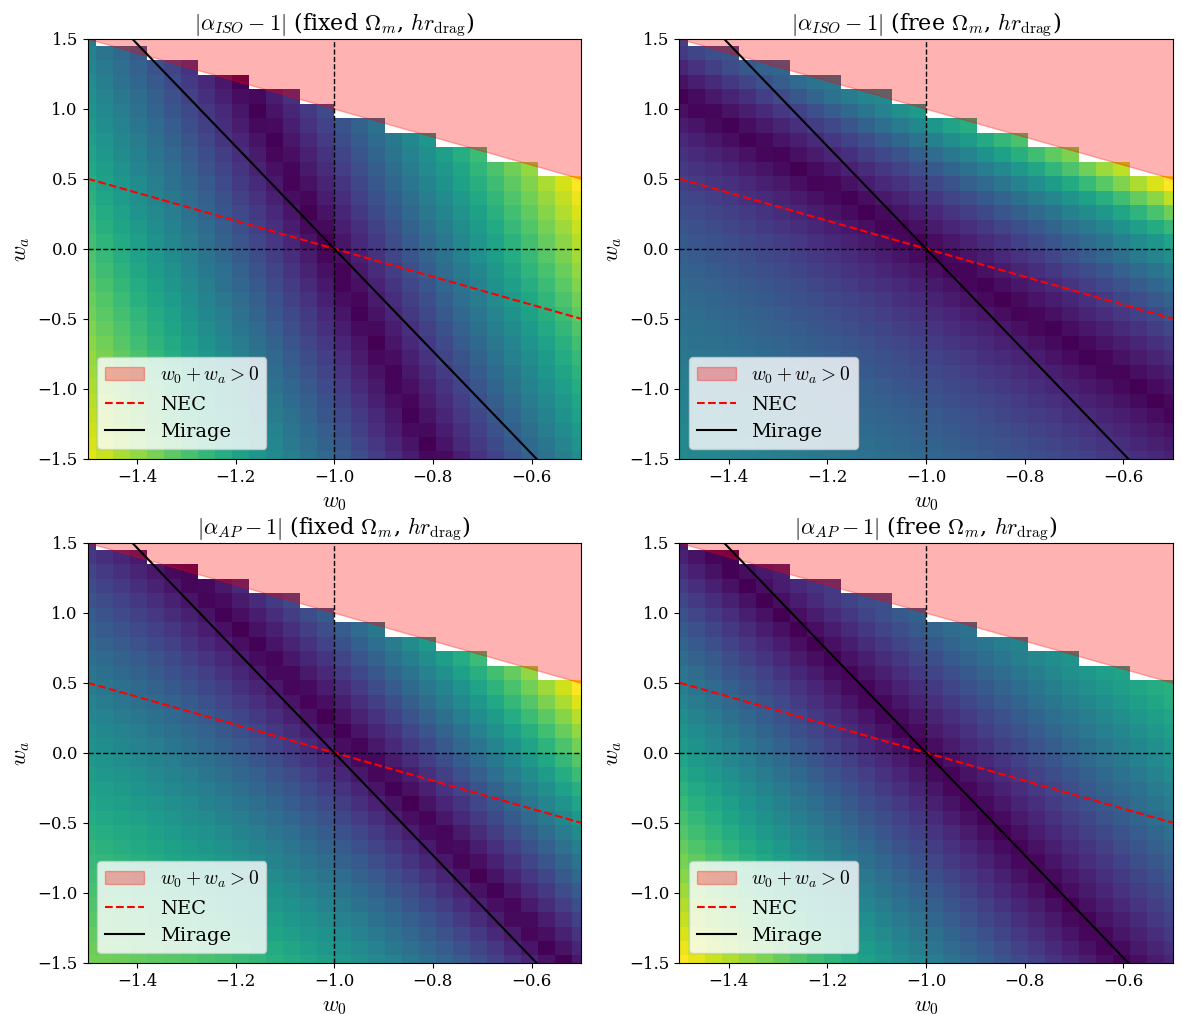

In [122]:
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
# axs[0, 0].contourf(w0_grid, wa_grid, dev_iso_fixed.T, levels=20, cmap='viridis')
axs[0, 0].pcolormesh(w0_grid, wa_grid, dev_iso_fixed.T, cmap='viridis')
axs[0, 0].set_title(r'$|\alpha_{ISO}-1|$ (fixed $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

# axs[0, 1].contourf(w0_grid, wa_grid, dev_iso_free.T, levels=20, cmap='viridis')
axs[0, 1].pcolormesh(w0_grid, wa_grid, dev_iso_free.T, cmap='viridis')
axs[0, 1].set_title(r'$|\alpha_{ISO}-1|$ (free $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

# axs[1, 0].contourf(w0_grid, wa_grid, dev_AP_fixed.T, levels=20, cmap='viridis')
axs[1, 0].pcolormesh(w0_grid, wa_grid, dev_AP_fixed.T, cmap='viridis')
axs[1, 0].set_title(r'$|\alpha_{AP}-1|$ (fixed $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

# axs[1, 1].contourf(w0_grid, wa_grid, dev_AP_free.T, levels=20, cmap='viridis')
axs[1, 1].pcolormesh(w0_grid, wa_grid, dev_AP_free.T, cmap='viridis')
axs[1, 1].set_title(r'$|\alpha_{AP}-1|$ (free $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

for ax in axs.flat:
    w0_line = np.linspace(-1.6, -0.4, 100)
    ax.fill_between(w0_line, -w0_line, 1.5, color='red', alpha=0.3, label=r'$w_0 + w_a > 0$')
    ax.plot(w0_range, -(1+w0_range), 'r--', label=r'NEC')
    ax.plot(w0_range, -3.66*(1+w0_range), 'k-', label=r'Mirage')
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.axvline(-1, color='k', linestyle='--', linewidth=1)

    ax.set_xlim(-1.5, -0.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel(r'$w_0$', fontsize=16)
    ax.set_ylabel(r'$w_a$', fontsize=16)
    ax.legend()

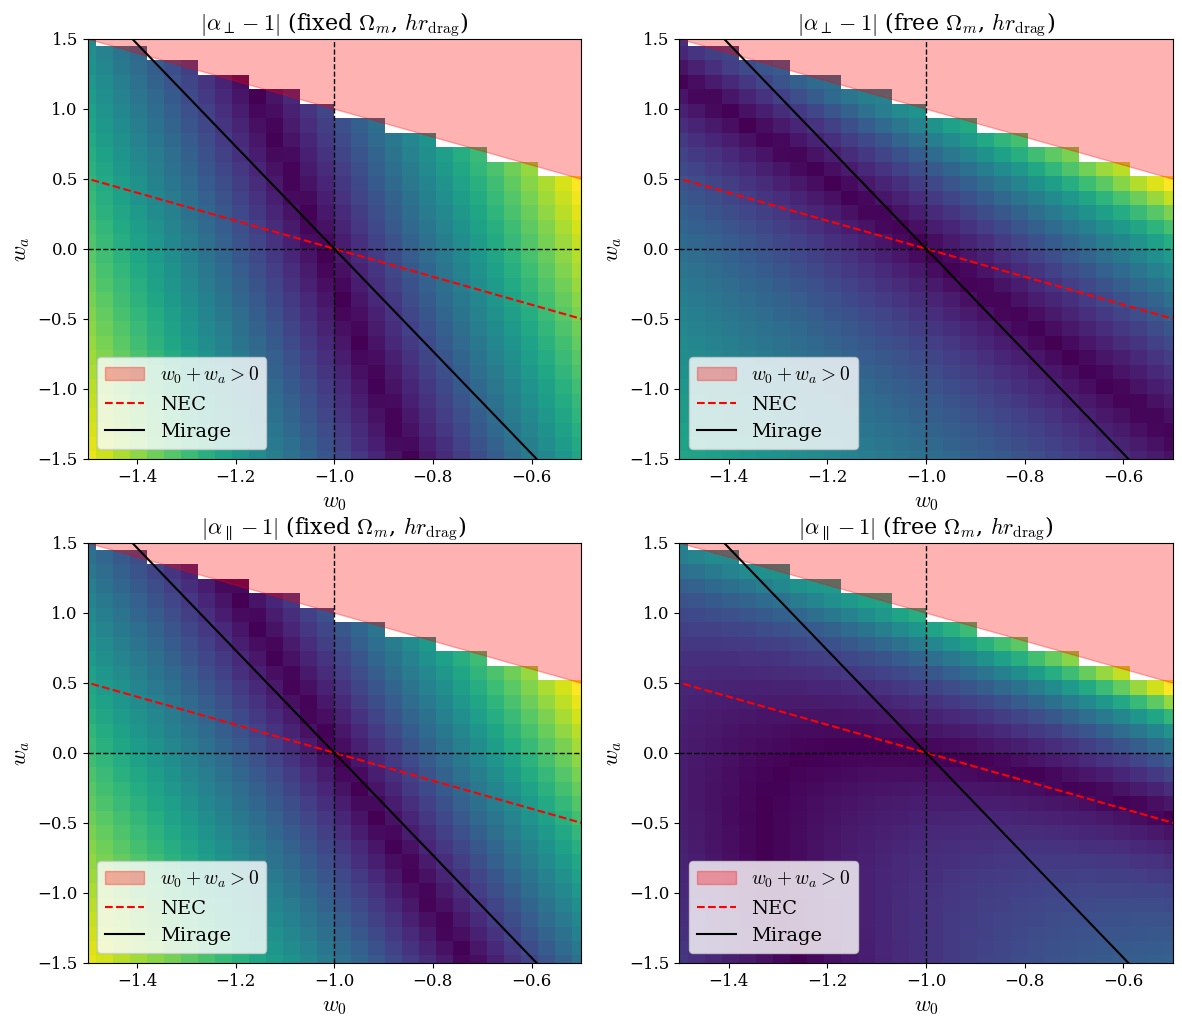

In [123]:
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
# axs[0, 0].contourf(w0_grid, wa_grid, dev_iso_fixed.T, levels=20, cmap='viridis')
axs[0, 0].pcolormesh(w0_grid, wa_grid, dev_perp_fixed.T, cmap='viridis')
axs[0, 0].set_title(r'$|\alpha_{\perp}-1|$ (fixed $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

# axs[0, 1].contourf(w0_grid, wa_grid, dev_iso_free.T, levels=20, cmap='viridis')
axs[0, 1].pcolormesh(w0_grid, wa_grid, dev_perp_free.T, cmap='viridis')
axs[0, 1].set_title(r'$|\alpha_{\perp}-1|$ (free $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

# axs[1, 0].contourf(w0_grid, wa_grid, dev_AP_fixed.T, levels=20, cmap='viridis')
axs[1, 0].pcolormesh(w0_grid, wa_grid, dev_par_fixed.T, cmap='viridis')
axs[1, 0].set_title(r'$|\alpha_{\parallel}-1|$ (fixed $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

# axs[1, 1].contourf(w0_grid, wa_grid, dev_AP_free.T, levels=20, cmap='viridis')
axs[1, 1].pcolormesh(w0_grid, wa_grid, dev_par_free.T, cmap='viridis')
axs[1, 1].set_title(r'$|\alpha_{\parallel}-1|$ (free $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

for ax in axs.flat:
    w0_line = np.linspace(-1.6, -0.4, 10)
    ax.fill_between(w0_line, -w0_line, 1.5, color='red', alpha=0.3, label=r'$w_0 + w_a > 0$')
    ax.plot(w0_line, -(1+w0_line), 'r--', label=r'NEC')
    ax.plot(w0_line, -3.66*(1+w0_line), 'k-', label=r'Mirage')
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.axvline(-1, color='k', linestyle='--', linewidth=1)

    ax.set_xlim(-1.5, -0.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel(r'$w_0$', fontsize=16)
    ax.set_ylabel(r'$w_a$', fontsize=16)
    ax.legend()

## integrated over redshift range

In [9]:
alph_perp_fixed = np.full(w0_grid.shape, np.nan)
alph_par_fixed  = np.full(w0_grid.shape, np.nan)
alph_AP_fixed   = np.full(w0_grid.shape, np.nan)
alph_ISO_fixed  = np.full(w0_grid.shape, np.nan)

for i, w0 in enumerate(w0_range):
    for j, wa in enumerate(wa_range):
        if w0 + wa <= 0:
            Om = Omega_m_grid_fixed[j, i]
            hrdrag = hrdrag_grid_fixed[j, i]
            param_cosmo = (w0, wa, Om, hrdrag)
            result = integrated_alpha(z_bins[0], param_cosmo)
            alph_perp_fixed[i, j] = result[0]
            alph_par_fixed[i, j] = result[1]
            alph_AP_fixed[i, j] = result[2]
            alph_ISO_fixed[i, j] = result[3]
        else:
            alph_perp_fixed[i, j] = np.nan
            alph_par_fixed[i, j] = np.nan
            alph_AP_fixed[i, j] = np.nan
            alph_ISO_fixed[i, j] = np.nan

In [10]:
int_dev_iso_fixed = alph_ISO_fixed
int_dev_AP_fixed = alph_AP_fixed
int_dev_perp_fixed = alph_perp_fixed
int_dev_par_fixed = alph_par_fixed

In [11]:
alph_perp_free = np.full(w0_grid.shape, np.nan)
alph_par_free  = np.full(w0_grid.shape, np.nan)
alph_AP_free   = np.full(w0_grid.shape, np.nan)
alph_ISO_free  = np.full(w0_grid.shape, np.nan)

for i, w0 in enumerate(w0_range):
    for j, wa in enumerate(wa_range):
        if w0 + wa <= 0:
            Om = Omega_m_grid_free[j, i]
            hrdrag = hrdrag_grid_free[j, i]
            param_cosmo = (w0, wa, Om, hrdrag)
            result = integrated_alpha(z_bins[0], param_cosmo)
            alph_perp_fixed[i, j] = result[0]
            alph_par_fixed[i, j] = result[1]
            alph_AP_fixed[i, j] = result[2]
            alph_ISO_fixed[i, j] = result[3]
        else:
            alph_perp_free[i, j] = np.nan
            alph_par_free[i, j] = np.nan
            alph_AP_free[i, j] = np.nan
            alph_ISO_free[i, j] = np.nan

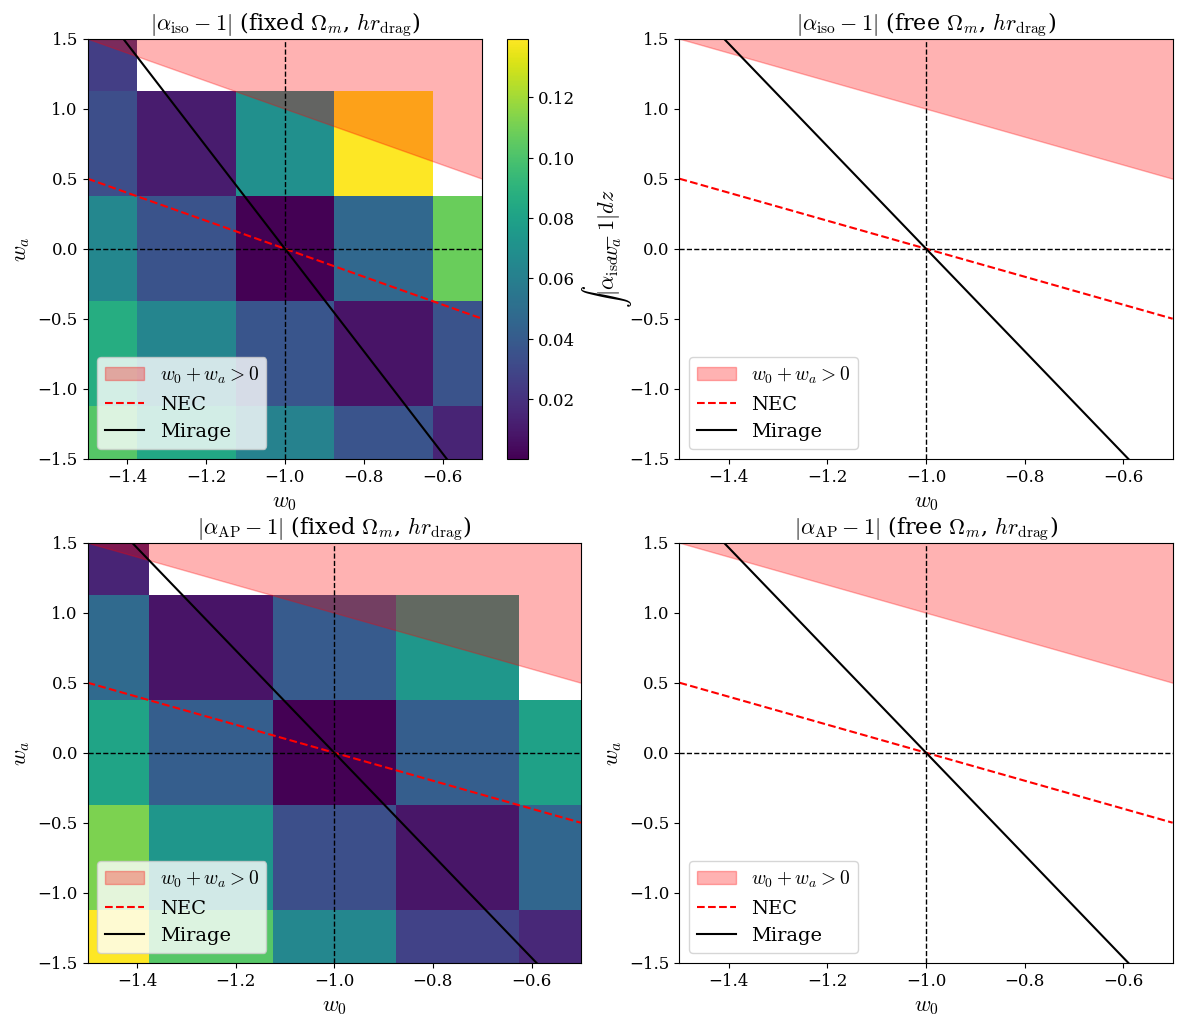

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
# axs[0, 0].contourf(w0_grid, wa_grid, dev_iso_fixed.T, levels=20, cmap='viridis')
axs[0, 0].pcolormesh(w0_grid, wa_grid, int_dev_iso_fixed.T, cmap='viridis')
axs[0, 0].set_title(r'$|\alpha_\mathrm{iso}-1|$ (fixed $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

# axs[0, 1].contourf(w0_grid, wa_grid, dev_iso_free.T, levels=20, cmap='viridis')
axs[0, 1].pcolormesh(w0_grid, wa_grid, alph_ISO_free.T, cmap='viridis')
axs[0, 1].set_title(r'$|\alpha_\mathrm{iso}-1|$ (free $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

# axs[1, 0].contourf(w0_grid, wa_grid, dev_AP_fixed.T, levels=20, cmap='viridis')
axs[1, 0].pcolormesh(w0_grid, wa_grid, int_dev_AP_fixed.T, cmap='viridis')
axs[1, 0].set_title(r'$|\alpha_\mathrm{AP}-1|$ (fixed $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

# axs[1, 1].contourf(w0_grid, wa_grid, dev_AP_free.T, levels=20, cmap='viridis')
axs[1, 1].pcolormesh(w0_grid, wa_grid, alph_AP_free.T, cmap='viridis')
axs[1, 1].set_title(r'$|\alpha_\mathrm{AP}-1|$ (free $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

plt.colorbar(axs[0, 0].collections[0], ax=axs[0, 0], label=r'$\int |\alpha_\mathrm{iso}-1| dz$')

for ax in axs.flat:
    w0_line = np.linspace(-1.6, -0.4, 100)
    ax.fill_between(w0_line, -w0_line, 1.5, color='red', alpha=0.3, label=r'$w_0 + w_a > 0$')
    ax.plot(w0_range, -(1+w0_range), 'r--', label=r'NEC')
    ax.plot(w0_range, -3.66*(1+w0_range), 'k-', label=r'Mirage')
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.axvline(-1, color='k', linestyle='--', linewidth=1)

    ax.set_xlim(-1.5, -0.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel(r'$w_0$', fontsize=16)
    ax.set_ylabel(r'$w_a$', fontsize=16)
    ax.legend()

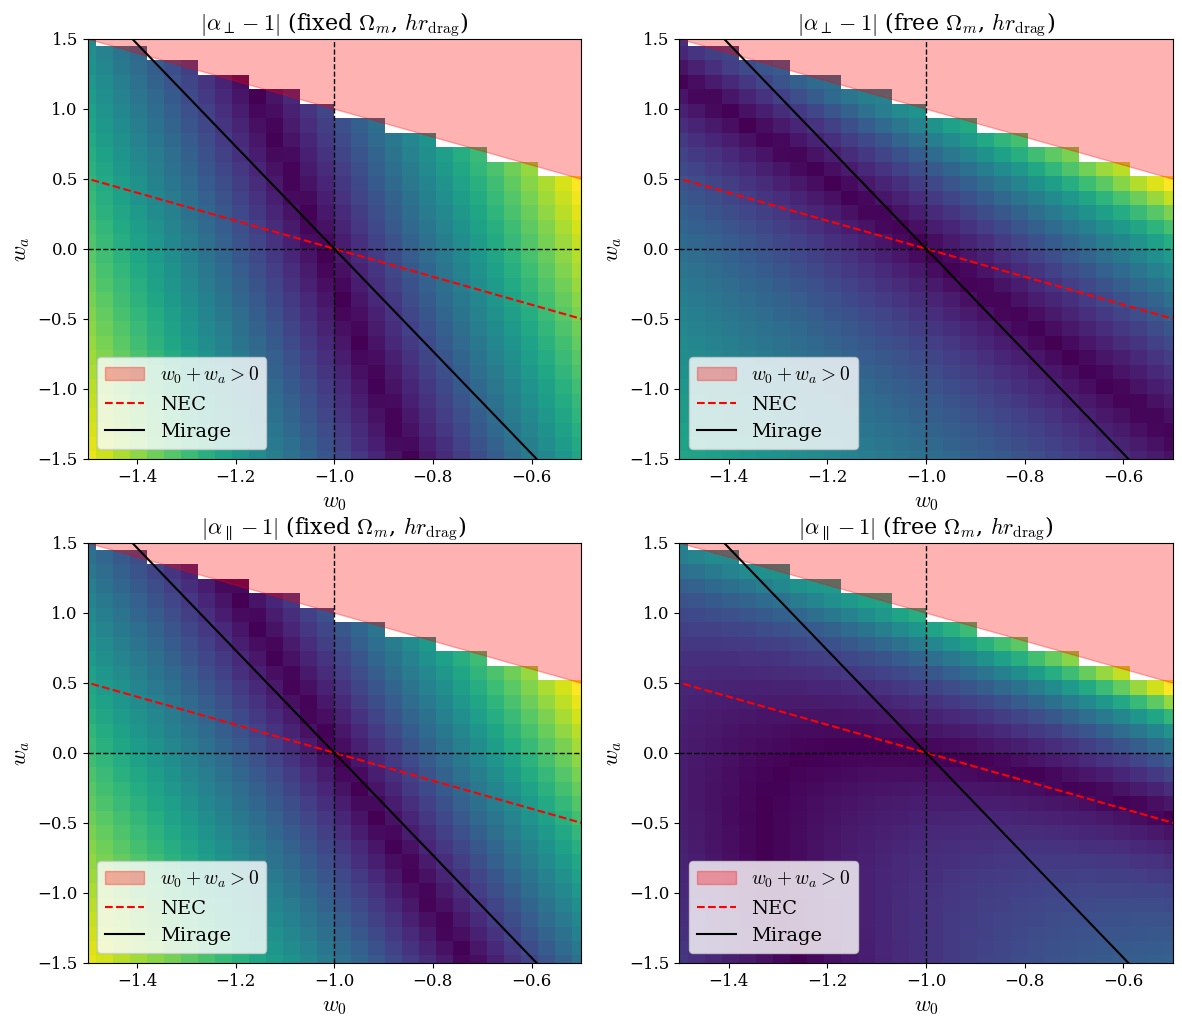

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
# axs[0, 0].contourf(w0_grid, wa_grid, dev_iso_fixed.T, levels=20, cmap='viridis')
axs[0, 0].pcolormesh(w0_grid, wa_grid, dev_perp_fixed.T, cmap='viridis')
axs[0, 0].set_title(r'$|\alpha_{\perp}-1|$ (fixed $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

# axs[0, 1].contourf(w0_grid, wa_grid, dev_iso_free.T, levels=20, cmap='viridis')
axs[0, 1].pcolormesh(w0_grid, wa_grid, dev_perp_free.T, cmap='viridis')
axs[0, 1].set_title(r'$|\alpha_{\perp}-1|$ (free $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

# axs[1, 0].contourf(w0_grid, wa_grid, dev_AP_fixed.T, levels=20, cmap='viridis')
axs[1, 0].pcolormesh(w0_grid, wa_grid, dev_par_fixed.T, cmap='viridis')
axs[1, 0].set_title(r'$|\alpha_{\parallel}-1|$ (fixed $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

# axs[1, 1].contourf(w0_grid, wa_grid, dev_AP_free.T, levels=20, cmap='viridis')
axs[1, 1].pcolormesh(w0_grid, wa_grid, dev_par_free.T, cmap='viridis')
axs[1, 1].set_title(r'$|\alpha_{\parallel}-1|$ (free $\Omega_m$, $hr_\mathrm{drag}$)', fontsize=16)

for ax in axs.flat:
    w0_line = np.linspace(-1.6, -0.4, 10)
    ax.fill_between(w0_line, -w0_line, 1.5, color='red', alpha=0.3, label=r'$w_0 + w_a > 0$')
    ax.plot(w0_line, -(1+w0_line), 'r--', label=r'NEC')
    ax.plot(w0_line, -3.66*(1+w0_line), 'k-', label=r'Mirage')
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.axvline(-1, color='k', linestyle='--', linewidth=1)

    ax.set_xlim(-1.5, -0.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel(r'$w_0$', fontsize=16)
    ax.set_ylabel(r'$w_a$', fontsize=16)
    ax.legend()

## over the 3 redshift range

In [ ]:
# dev_perp_fixed_bin = [np.full(w0_grid.shape, np.nan) for _ in range(len(z_bins))]
# dev_par_fixed_bin  = [np.full(w0_grid.shape, np.nan) for _ in range(len(z_bins))]
# dev_AP_fixed_bin   = [np.full(w0_grid.shape, np.nan) for _ in range(len(z_bins))]
# dev_ISO_fixed_bin  = [np.full(w0_grid.shape, np.nan) for _ in range(len(z_bins))]

# for h in range(len(z_bins)):
#     for i, w0 in enumerate(w0_range):
#         for j, wa in enumerate(wa_range):
#             if w0 + wa <= 0:
#                 Om = 0.3
#                 hrdrag = 100
#                 param_cosmo = (w0, wa, Om, hrdrag)
#                 result = integrated_alpha(z_bins[h], param_cosmo)
#                 dev_perp_fixed_bin[h][i, j] = result[0]
#                 dev_par_fixed_bin[h][i, j] = result[1]
#                 dev_AP_fixed_bin[h][i, j] = result[2]
#                 dev_ISO_fixed_bin[h][i, j] = result[3]
#             else:
#                 dev_perp_fixed_bin[h][i, j] = np.nan
#                 dev_par_fixed_bin[h][i, j] = np.nan
#                 dev_AP_fixed_bin[h][i, j] = np.nan
#                 dev_ISO_fixed_bin[h][i, j] = np.nan

In [ ]:
# # save the binned deviations for later use
# np.save(r'..\..\sym_colormap_grids\dev_perp_fixed_bin.npy', dev_perp_fixed_bin)
# np.save(r'..\..\sym_colormap_grids\dev_par_fixed_bin.npy', dev_par_fixed_bin)
# np.save(r'..\..\sym_colormap_grids\dev_AP_fixed_bin.npy', dev_AP_fixed_bin)
# np.save(r'..\..\sym_colormap_grids\dev_ISO_fixed_bin.npy', dev_ISO_fixed_bin)

In [ ]:
# dev_perp_free_bin = [np.full(w0_grid.shape, np.nan) for _ in range(len(z_bins))]
# dev_par_free_bin  = [np.full(w0_grid.shape, np.nan) for _ in range(len(z_bins))]
# dev_AP_free_bin   = [np.full(w0_grid.shape, np.nan) for _ in range(len(z_bins))]
# dev_ISO_free_bin  = [np.full(w0_grid.shape, np.nan) for _ in range(len(z_bins))]

# for h in range(len(z_bins)):
#     for i, w0 in enumerate(w0_range):
#         for j, wa in enumerate(wa_range):
#             if w0 + wa <= 0:
#                 Om = Omega_m_grid_free[j, i]
#                 hrdrag = hrdrag_grid_free[j, i]
#                 param_cosmo = (w0, wa, Om, hrdrag)
#                 result = integrated_alpha(z_bins[h], param_cosmo)
#                 dev_perp_free_bin[h][i, j] = result[0]
#                 dev_par_free_bin[h][i, j] = result[1]
#                 dev_AP_free_bin[h][i, j] = result[2]
#                 dev_ISO_free_bin[h][i, j] = result[3]
#             else:
#                 dev_perp_free_bin[h][i, j] = np.nan
#                 dev_par_free_bin[h][i, j] = np.nan
#                 dev_AP_free_bin[h][i, j] = np.nan
#                 dev_ISO_free_bin[h][i, j] = np.nan

In [ ]:
# # save the binned deviations for later use
# np.save(r'..\..\sym_colormap_grids\dev_perp_free_bin.npy', dev_perp_free_bin)
# np.save(r'..\..\sym_colormap_grids\dev_par_free_bin.npy', dev_par_free_bin)
# np.save(r'..\..\sym_colormap_grids\dev_AP_free_bin.npy', dev_AP_free_bin)
# np.save(r'..\..\sym_colormap_grids\dev_ISO_free_bin.npy', dev_ISO_free_bin)

In [13]:
# load the binned deviations for plotting (these are 40x40 grids)
dev_perp_fixed_bin = np.load(r'..\..\sym_colormap_grids\dev_perp_fixed_bin.npy', allow_pickle=True)
dev_par_fixed_bin = np.load(r'..\..\sym_colormap_grids\dev_par_fixed_bin.npy', allow_pickle=True)
dev_AP_fixed_bin = np.load(r'..\..\sym_colormap_grids\dev_AP_fixed_bin.npy', allow_pickle=True)
dev_ISO_fixed_bin = np.load(r'..\..\sym_colormap_grids\dev_ISO_fixed_bin.npy', allow_pickle=True)
dev_perp_free_bin = np.load(r'..\..\sym_colormap_grids\dev_perp_free_bin.npy', allow_pickle=True)
dev_par_free_bin = np.load(r'..\..\sym_colormap_grids\dev_par_free_bin.npy', allow_pickle=True)
dev_AP_free_bin = np.load(r'..\..\sym_colormap_grids\dev_AP_free_bin.npy', allow_pickle=True)
dev_ISO_free_bin = np.load(r'..\..\sym_colormap_grids\dev_ISO_free_bin.npy', allow_pickle=True)

In [14]:
# multiply everything by 1e2
dev_perp_fixed_bin = [dev * 1e2 for dev in dev_perp_fixed_bin]
dev_par_fixed_bin = [dev * 1e2 for dev in dev_par_fixed_bin]
dev_AP_fixed_bin = [dev * 1e2 for dev in dev_AP_fixed_bin]
dev_ISO_fixed_bin = [dev * 1e2 for dev in dev_ISO_fixed_bin]
dev_perp_free_bin = [dev * 1e2 for dev in dev_perp_free_bin]
dev_par_free_bin = [dev * 1e2 for dev in dev_par_free_bin]
dev_AP_free_bin = [dev * 1e2 for dev in dev_AP_free_bin]
dev_ISO_free_bin = [dev * 1e2 for dev in dev_ISO_free_bin]

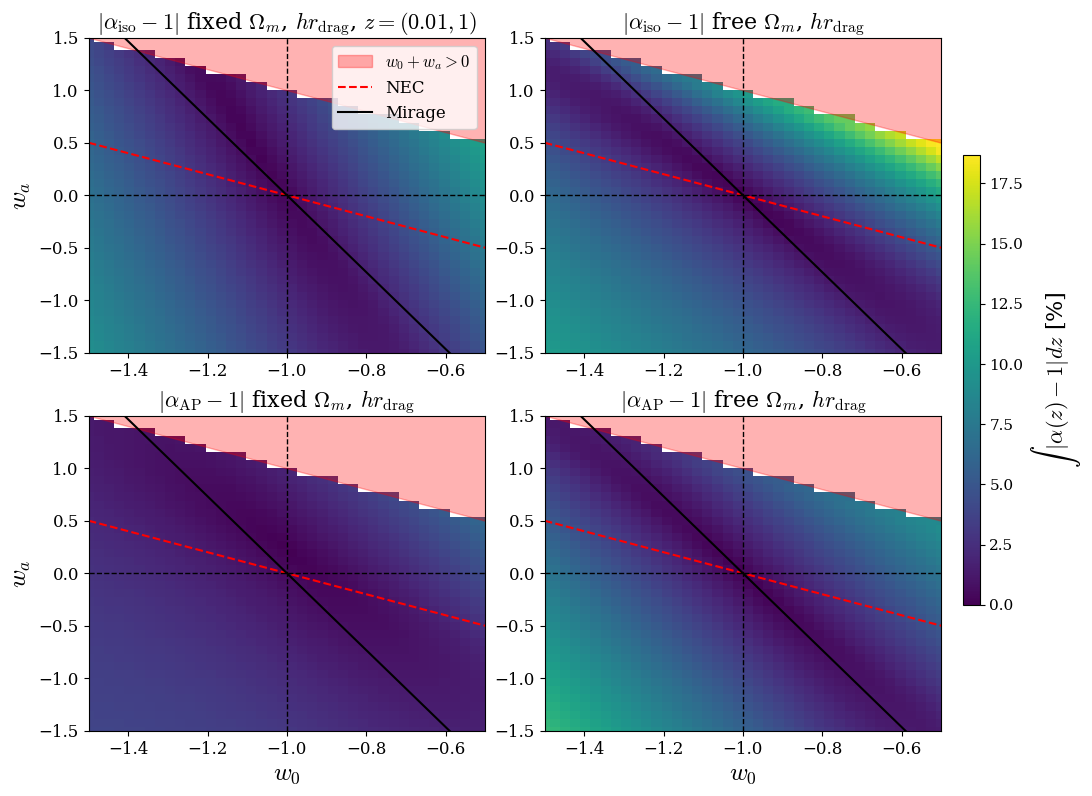

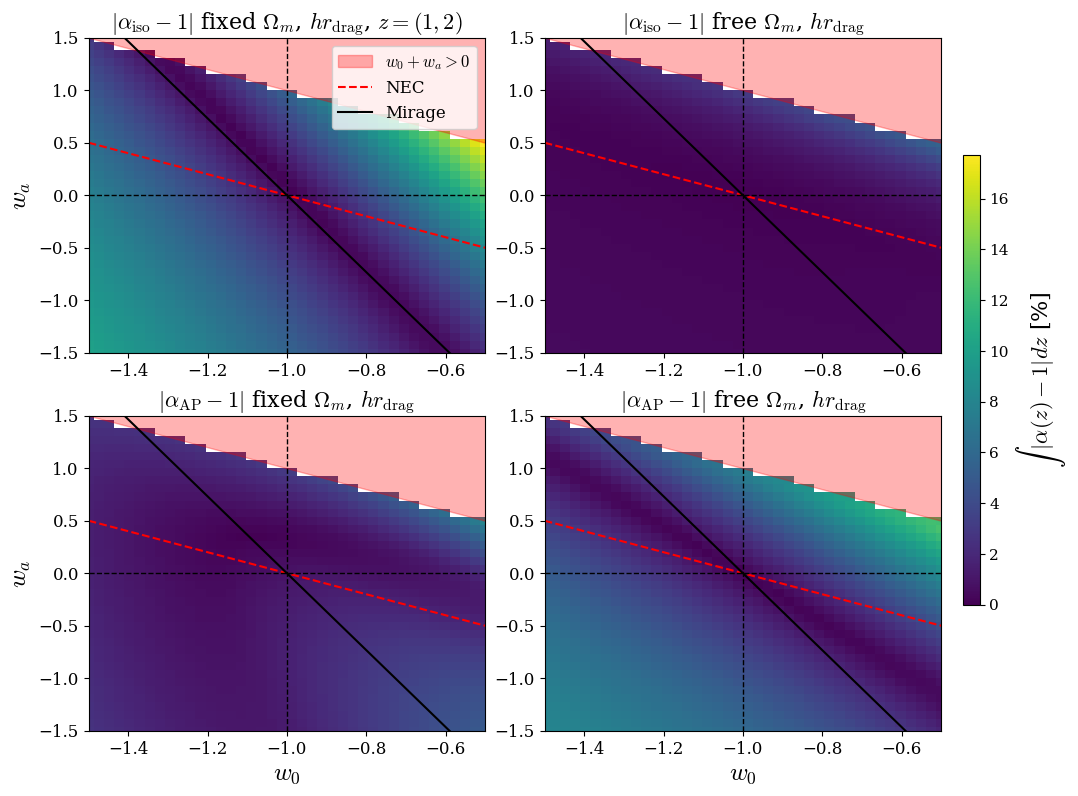

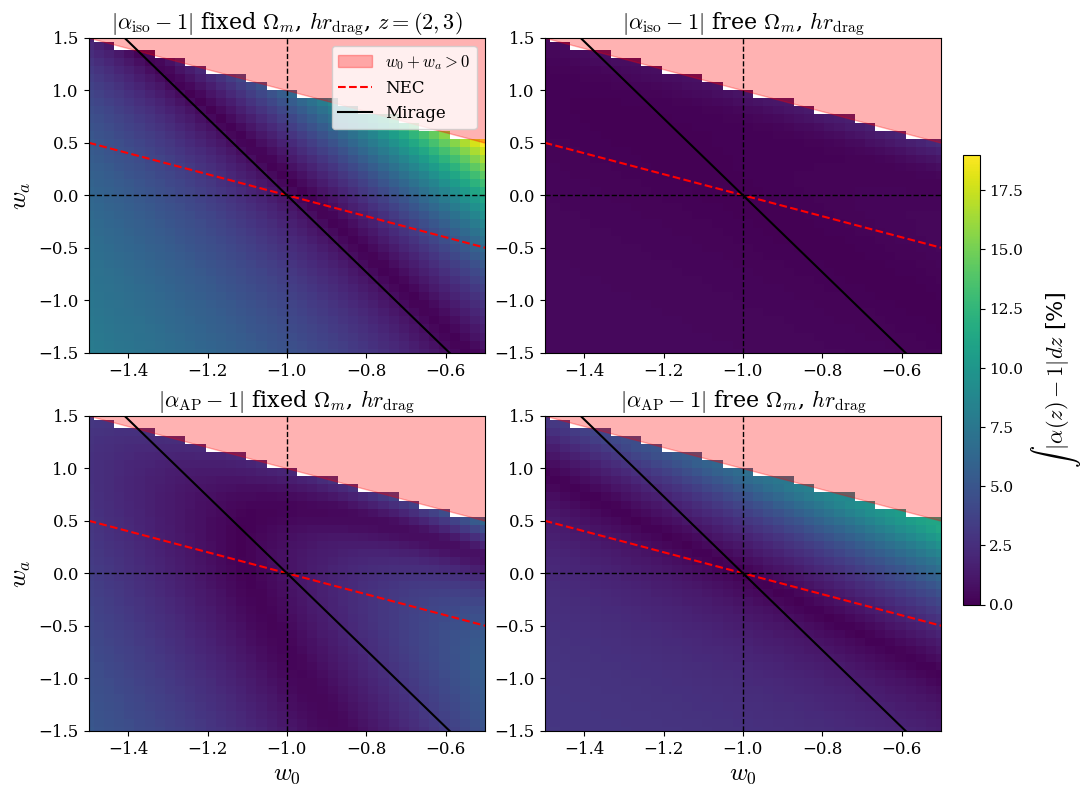

In [ ]:
for h in range(len(z_bins)):
    # fig, axs = plt.subplots(2, 2, figsize=(14, 12))
    fig = plt.figure(figsize=(11, 9))
    gs = fig.add_gridspec(
            2, 2,
        wspace=0.15, hspace=0.2
    )

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1])
    ax10 = fig.add_subplot(gs[1, 0])
    ax11 = fig.add_subplot(gs[1, 1])

    max_dev = max(np.nanmax(dev_ISO_fixed_bin[h]), np.nanmax(dev_ISO_free_bin[h]), np.nanmax(dev_AP_fixed_bin[h]), np.nanmax(dev_AP_free_bin[h]))
   
    norm = mcolors.Normalize(vmin=0, vmax=max_dev)
    cmap = cm.viridis
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.set_label(r'$\int \ |\alpha(z)-1| dz$ [%]', fontsize=16)
    cb.ax.tick_params(labelsize=11)

    # axs[0, 0].contourf(w0_grid, wa_grid, dev_iso_fixed.T, levels=20, cmap='viridis') # interpolate and draws contours for smoother visualization, but can be misleading for small grids
    ax00.pcolormesh(w0_grid, wa_grid, dev_ISO_fixed_bin[h].T, cmap=cmap, norm=norm)
    ax00.set_title(r'$|\alpha_\mathrm{iso}-1|$ fixed $\Omega_m$, $hr_\mathrm{drag}$, $z = '+ str(z_bins[h])+r'$', fontsize=16)

    # axs[0, 1].contourf(w0_grid, wa_grid, dev_iso_free.T, levels=20, cmap='viridis')
    ax01.pcolormesh(w0_grid, wa_grid, dev_ISO_free_bin[h].T, cmap=cmap, norm=norm)
    ax01.set_title(r'$|\alpha_\mathrm{iso}-1|$ free $\Omega_m$, $hr_\mathrm{drag}$', fontsize=16)

    # axs[1, 0].contourf(w0_grid, wa_grid, dev_AP_fixed.T, levels=20, cmap='viridis')
    ax10.pcolormesh(w0_grid, wa_grid, dev_AP_fixed_bin[h].T, cmap=cmap, norm=norm)
    ax10.set_title(r'$|\alpha_\mathrm{AP}-1|$ fixed $\Omega_m$, $hr_\mathrm{drag}$', fontsize=16)

    # axs[1, 1].contourf(w0_grid, wa_grid, dev_AP_free.T, levels=20, cmap='viridis')
    ax11.pcolormesh(w0_grid, wa_grid, dev_AP_free_bin[h].T, cmap=cmap, norm=norm)
    ax11.set_title(r'$|\alpha_\mathrm{AP}-1|$ free $\Omega_m$, $hr_\mathrm{drag}$', fontsize=16)

    for ax in [ax00, ax01, ax10, ax11]:
        w0_line = np.linspace(-1.6, -0.4, 100)
        ax.fill_between(w0_line, -w0_line, 1.5, color='red', alpha=0.3, label=r'$w_0 + w_a > 0$')
        ax.plot(w0_range, -(1+w0_range), 'r--', label=r'NEC')
        ax.plot(w0_range, -3.66*(1+w0_range), 'k-', label=r'Mirage')
        ax.axhline(0, color='k', linestyle='--', linewidth=1)
        ax.axvline(-1, color='k', linestyle='--', linewidth=1)

        ax.set_xlim(-1.5, -0.5)
        ax.set_ylim(-1.5, 1.5)

    ax10.set_xlabel(r'$w_0$', fontsize=18)
    ax11.set_xlabel(r'$w_0$', fontsize=18)
    ax00.set_ylabel(r'$w_a$', fontsize=18)
    ax10.set_ylabel(r'$w_a$', fontsize=18)
    ax00.legend(loc='upper right', fontsize=12)
    
    # plt.tight_layout()
    # plt.savefig(f'../../figures/alpha_deviation/integrated_zbin/iso_AP_zbin_{h}.png', bbox_inches='tight', dpi=150)

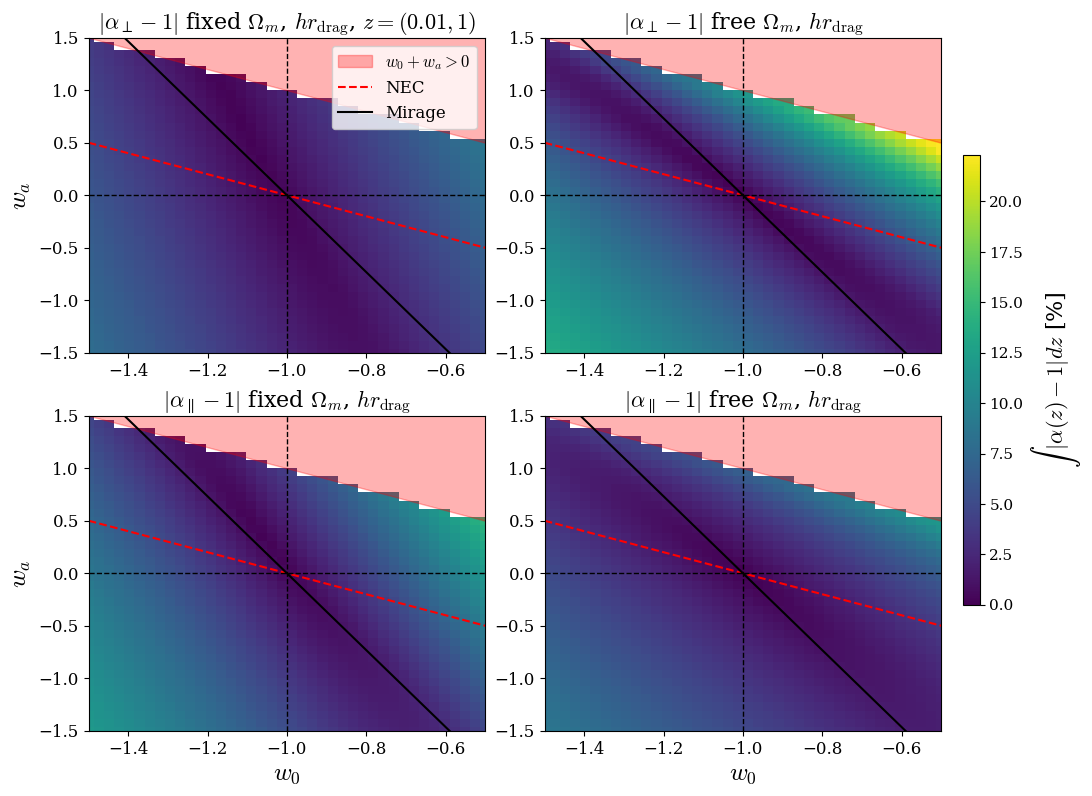

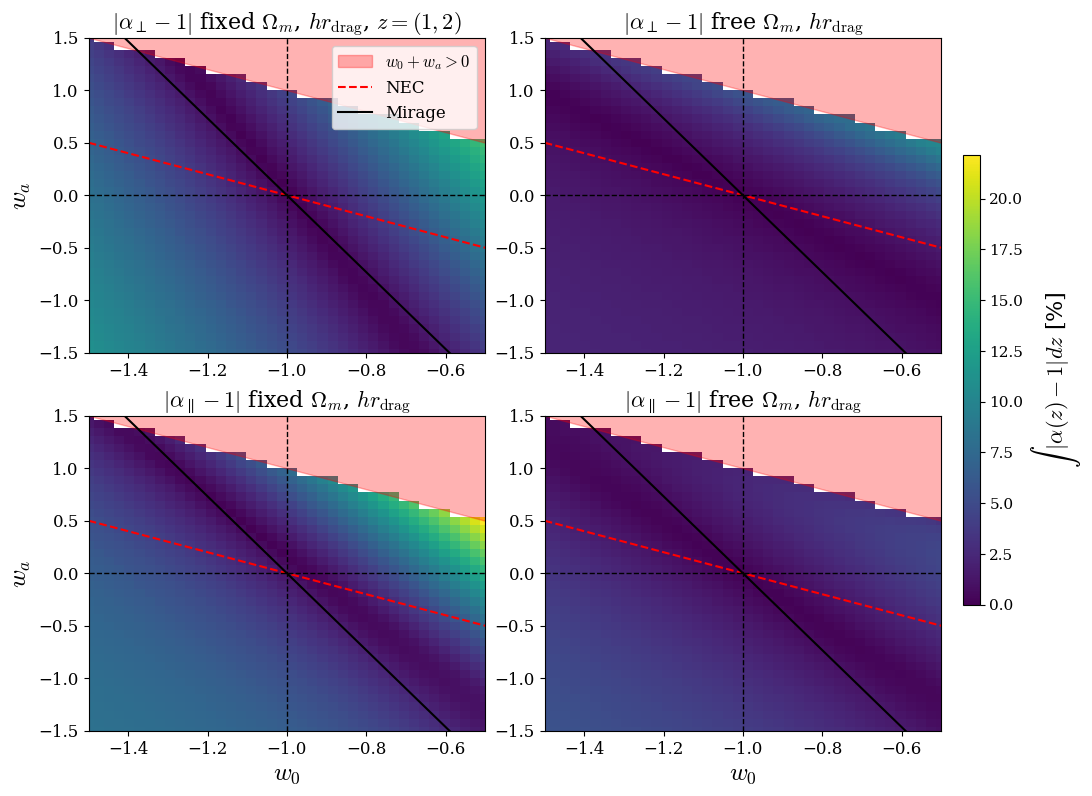

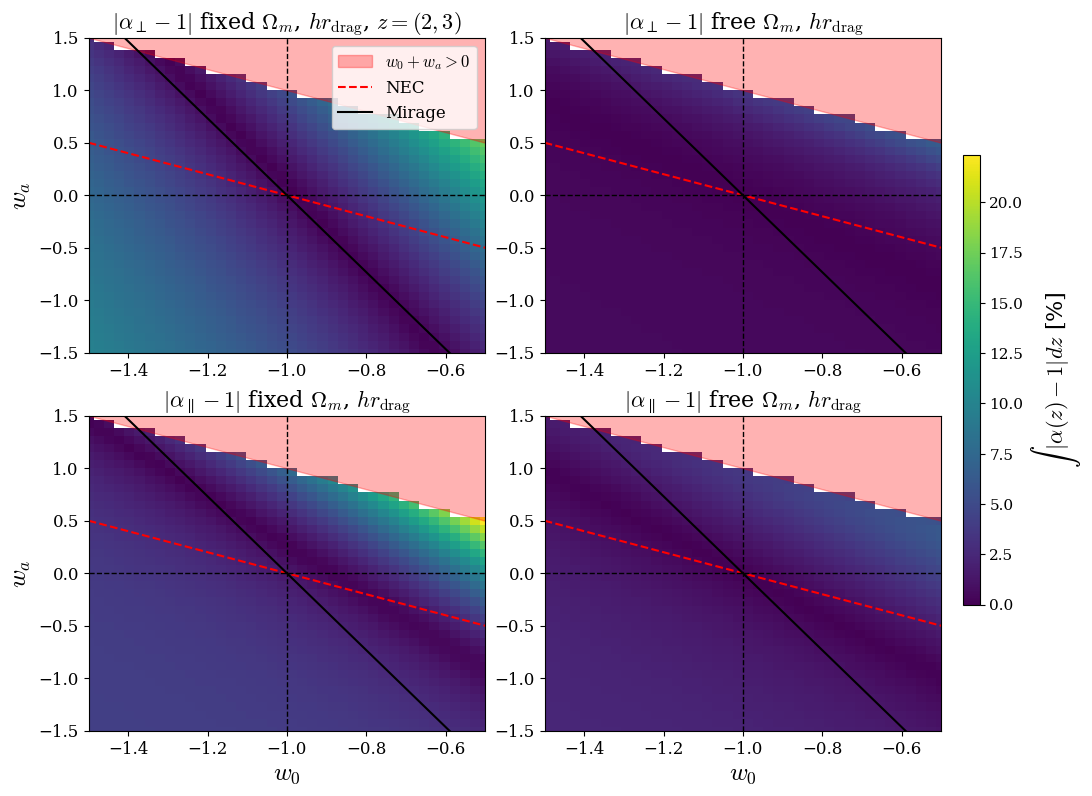

In [ ]:
for h in range(len(z_bins)):
    # fig, axs = plt.subplots(2, 2, figsize=(14, 12))
    fig = plt.figure(figsize=(11, 9))
    gs = fig.add_gridspec(
            2, 2,
        wspace=0.15, hspace=0.2
    )

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1])
    ax10 = fig.add_subplot(gs[1, 0])
    ax11 = fig.add_subplot(gs[1, 1])

    max_dev = max(np.nanmax(dev_perp_fixed_bin[h]), np.nanmax(dev_perp_free_bin[h]), np.nanmax(dev_par_fixed_bin[h]), np.nanmax(dev_par_free_bin[h]))
   
    norm = mcolors.Normalize(vmin=0, vmax=max_dev)
    cmap = cm.viridis
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.set_label(r'$\int \ |\alpha(z)-1| dz$ [%]', fontsize=16)
    cb.ax.tick_params(labelsize=11)

    # axs[0, 0].contourf(w0_grid, wa_grid, dev_iso_fixed.T, levels=20, cmap='viridis') # interpolate and draws contours for smoother visualization, but can be misleading for small grids
    ax00.pcolormesh(w0_grid, wa_grid, dev_perp_fixed_bin[h].T, cmap=cmap, norm=norm)
    ax00.set_title(r'$|\alpha_\perp-1|$ fixed $\Omega_m$, $hr_\mathrm{drag}$, $z = '+ str(z_bins[h])+r'$', fontsize=16)

    # axs[0, 1].contourf(w0_grid, wa_grid, dev_iso_free.T, levels=20, cmap='viridis')
    ax01.pcolormesh(w0_grid, wa_grid, dev_perp_free_bin[h].T, cmap=cmap, norm=norm)
    ax01.set_title(r'$|\alpha_\perp-1|$ free $\Omega_m$, $hr_\mathrm{drag}$', fontsize=16)

    # axs[1, 0].contourf(w0_grid, wa_grid, dev_AP_fixed.T, levels=20, cmap='viridis')
    ax10.pcolormesh(w0_grid, wa_grid, dev_par_fixed_bin[h].T, cmap=cmap, norm=norm)
    ax10.set_title(r'$|\alpha_\parallel-1|$ fixed $\Omega_m$, $hr_\mathrm{drag}$', fontsize=16)

    # axs[1, 1].contourf(w0_grid, wa_grid, dev_AP_free.T, levels=20, cmap='viridis')
    ax11.pcolormesh(w0_grid, wa_grid, dev_par_free_bin[h].T, cmap=cmap, norm=norm)
    ax11.set_title(r'$|\alpha_\parallel-1|$ free $\Omega_m$, $hr_\mathrm{drag}$', fontsize=16)

    for ax in [ax00, ax01, ax10, ax11]:
        w0_line = np.linspace(-1.6, -0.4, 100)
        ax.fill_between(w0_line, -w0_line, 1.5, color='red', alpha=0.3, label=r'$w_0 + w_a > 0$')
        ax.plot(w0_range, -(1+w0_range), 'r--', label=r'NEC')
        ax.plot(w0_range, -3.66*(1+w0_range), 'k-', label=r'Mirage')
        ax.axhline(0, color='k', linestyle='--', linewidth=1)
        ax.axvline(-1, color='k', linestyle='--', linewidth=1)

        ax.set_xlim(-1.5, -0.5)
        ax.set_ylim(-1.5, 1.5)

    ax10.set_xlabel(r'$w_0$', fontsize=18)
    ax11.set_xlabel(r'$w_0$', fontsize=18)
    ax00.set_ylabel(r'$w_a$', fontsize=18)
    ax10.set_ylabel(r'$w_a$', fontsize=18)
    ax00.legend(loc='upper right', fontsize=12)
    
    # plt.tight_layout()
    # plt.savefig(f'../../figures/alpha_deviation/integrated_zbin/perp_par_zbin_{h}.png', bbox_inches='tight', dpi=150)